# Datathon Société Générale — Analyse des Dérivés Financiers BIS
## Dataset : Statistiques sur les dérivés de gré à gré (1986-2022)

**Contexte :** Datathon organisé par MBA ESG, ESG Executive, Bucharest University et Société Générale Global Solution Centre (Décembre 2024)

**Objectif :** Développer un assistant virtuel Gen AI pour analyser les données financières BIS et générer des datavisualisations pour le reporting interne de Société Générale.


## Structure du Dataset

**46 colonnes :**
- 33 colonnes descriptives (instrument, pays, devise, maturité...)
- 13 années de données (1986, 1989, 1992... 2022)

**Problèmes identifiés :**
- Format large → à transformer en format long (une ligne par année)
- Colonnes doublons (codes + libellés) → garder seulement les libellés
- Beaucoup de valeurs manquantes sur les anciennes années — normal pour des données historiques

**Données :** Volumes de dérivés financiers en milliards $ (FX swaps, Outright forwards, OIS...)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Chargement échantillon
df = pd.read_csv("../data/alteryx.csv", nrows=1000, low_memory=False)

print(f"Dimensions : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nAperçu :")
df.head(3)

Dimensions : (1000, 46)

Colonnes : ['FREQ', 'Frequency', 'DER_TYPE', 'Measure', 'DER_INSTR', 'Instrument', 'DER_RISK', 'Risk category', 'DER_REP_CTY', 'Reporting country', 'DER_SECTOR_CPY', 'Counterparty sector', 'DER_CPC', 'Counterparty country', 'DER_SECTOR_UDL', 'Underlying risk sector', 'DER_CURR_LEG1', 'Currency leg 1', 'DER_CURR_LEG2', 'Currency leg 2', 'DER_ISSUE_MAT', 'Maturity', 'DER_RATING', 'Rating (outstanding) or settlement (FX turnover)', 'DER_EX_METHOD', 'Execution method', 'DER_BASIS', 'Basis', 'AVAILABILITY', 'Availability2', 'COLLECTION', 'Collection Indicator', 'Series', '1986', '1989', '1992', '1995', '1998', '2001', '2004', '2007', '2010', '2013', '2016', '2019', '2022']

Aperçu :


,FREQ,Frequency,DER_TYPE,Measure,DER_INSTR,Instrument,DER_RISK,Risk category,DER_REP_CTY,Reporting country,...,1995,1998,2001,2004,2007,2010,2013,2016,2019,2022
0,A,Annual,U,Turnover - notional amounts (daily average),H,FX swaps,B,Foreign exchange,5J,All countries (total),...,NaN,NaN,NaN,NaN,3.744867,NaN,49.278497,18.477876,NaN,NaN
1,A,Annual,U,Turnover - notional amounts (daily average),E,Outright forwards,B,Foreign exchange,IE,Ireland,...,NaN,NaN,NaN,NaN,NaN,NaN,5.132740,0.376476,10.888817,NaN
2,A,Annual,U,Turnover - notional amounts (daily average),K,Overnight indexed swaps,D,Interest rate,5J,All countries (total),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.075910,191.663227


## Valeurs manquantes — Analyse

**Observation :** Les données anciennes (1986-2004) ont beaucoup de valeurs manquantes.
C'est normal — les marchés de dérivés étaient moins développés et le reporting moins standardisé.

**Stratégie de nettoyage :**
- Garder uniquement les lignes avec au moins une valeur non-nulle
- Transformer en format long pour faciliter l'analyse temporelle
- Supprimer les colonnes codes (doublons des libellés)

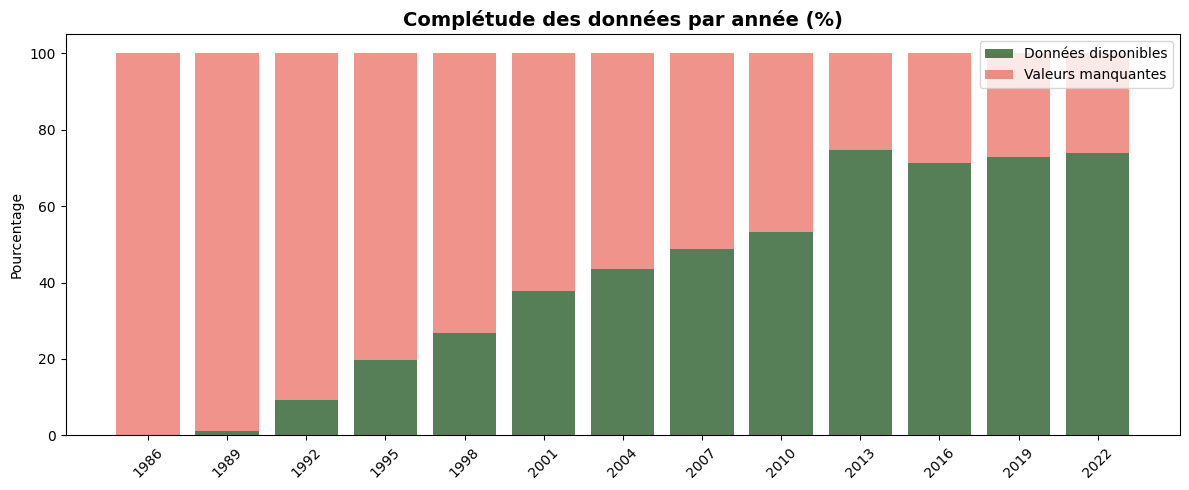

Complétude par année :
   1986 : 0.0% de données disponibles
   1989 : 1.0% de données disponibles
   1992 : 9.3% de données disponibles
   1995 : 19.6% de données disponibles
   1998 : 26.8% de données disponibles
   2001 : 37.9% de données disponibles
   2004 : 43.6% de données disponibles
   2007 : 48.9% de données disponibles
   2010 : 53.3% de données disponibles
   2013 : 74.7% de données disponibles
   2016 : 71.3% de données disponibles
   2019 : 72.8% de données disponibles
   2022 : 74.0% de données disponibles


In [2]:
# Analyse des valeurs manquantes par année
annees = ['1986','1989','1992','1995','1998','2001','2004','2007','2010','2013','2016','2019','2022']

missing_pct = df[annees].isnull().mean() * 100

plt.figure(figsize=(12, 5))
plt.bar(annees, 100 - missing_pct, color='#2C5F2D', alpha=0.8)
plt.bar(annees, missing_pct, bottom=100 - missing_pct, color='#E74C3C', alpha=0.6)
plt.title('Complétude des données par année (%)', fontsize=14, fontweight='bold')
plt.ylabel('Pourcentage')
plt.legend(['Données disponibles', 'Valeurs manquantes'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/completude_donnees.png', dpi=150)
plt.show()

print("Complétude par année :")
for annee in annees:
    pct = 100 - df[annee].isnull().mean() * 100
    print(f"   {annee} : {pct:.1f}% de données disponibles")

## Interprétation — Complétude des données

**1986-1992 : moins de 10% de données disponibles**
→ Données inutilisables — les marchés de dérivés étaient embryonnaires
et le reporting international non standardisé.

**1995-2010 : progression constante (20% → 54%)**
→ Reflet du développement rapide des marchés de dérivés
et de la mise en place progressive des standards BIS.

**2013-2022 : 72-75% de complétude**
→ Période retenue pour notre analyse — données fiables et représentatives.
Le reporting s'est stabilisé après les réformes post-crise 2008 (Bâle III).

**Décision :** On travaille uniquement sur la période **2013-2022**.

## Décision de nettoyage

Sur la base de cette analyse, on retient :
- **Années 2013-2022** uniquement → complétude > 70%
- **Suppression** des colonnes codes redondants
- **Transformation** format large → format long
- **Focus** sur les instruments les plus représentés : FX swaps, Outright forwards, OIS

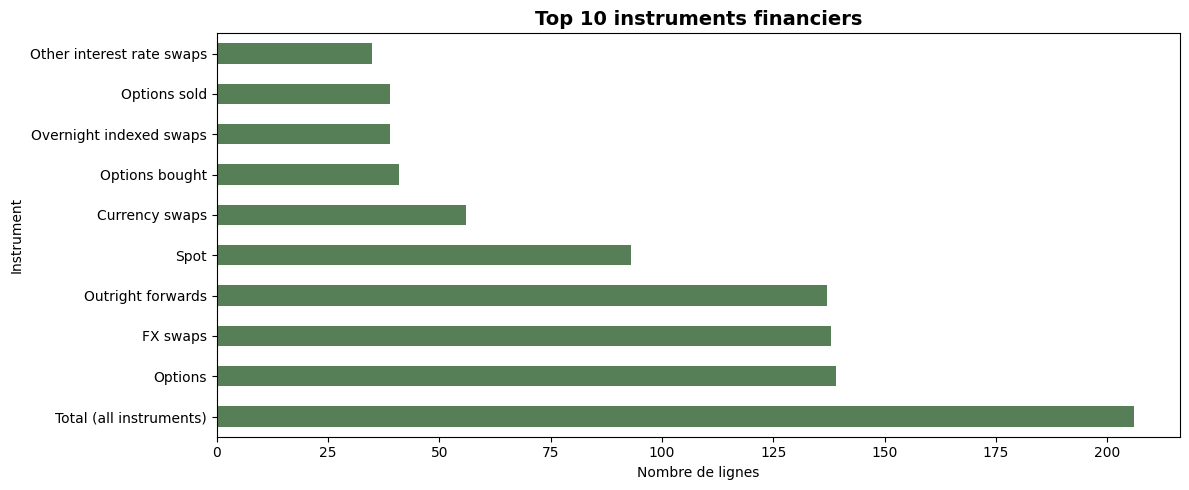

Top 10 instruments :
Instrument
Total (all instruments)      206
Options                      139
FX swaps                     138
Outright forwards            137
Spot                          93
Currency swaps                56
Options bought                41
Overnight indexed swaps       39
Options sold                  39
Other interest rate swaps     35
Name: count, dtype: int64


In [3]:
# Top instruments les plus représentés
top_instr = df['Instrument'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_instr.plot(kind='barh', color='#2C5F2D', alpha=0.8)
plt.title('Top 10 instruments financiers', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de lignes')
plt.tight_layout()
plt.savefig('../outputs/top_instruments.png', dpi=150)
plt.show()

print("Top 10 instruments :")
print(top_instr)

## Interprétation — Top 10 instruments financiers

**Total (all instruments) : 206 lignes** → ligne agrégée à exclure des analyses détaillées

**Top 3 instruments réels :**
- **Options : 139 lignes** → contrats d'options sur devises et taux
- **FX swaps : 138 lignes** → échanges de devises à terme — instrument dominant
- **Outright forwards : 135 lignes** → contrats à terme fermes sur devises

**Instruments de taux :**
- Currency swaps, OIS, Other interest rate swaps → marché de taux d'intérêt

**Décision :** On focalisera l'analyse sur **FX swaps** et **Outright forwards**
car ce sont les instruments les plus représentatifs du marché des changes
— domaine principal de Société Générale Global Solution Centre.

In [4]:
# Nettoyage final — Format long sur 2013-2022
annees_retenues = ['2013', '2016', '2019', '2022']

cols_meta = ['Instrument', 'Risk category', 'Reporting country',
             'Currency leg 1', 'Currency leg 2', 'Maturity',
             'Execution method', 'Basis']

# Supprimer la ligne Total
df_clean = df[df['Instrument'] != 'Total (all instruments)'].copy()

# Format long
df_long = df_clean.melt(
    id_vars=cols_meta,
    value_vars=annees_retenues,
    var_name='annee',
    value_name='volume_milliards'
)
df_long['annee'] = df_long['annee'].astype(int)
df_long = df_long.dropna(subset=['volume_milliards'])

print(f"Dataset final : {df_long.shape[0]:,} lignes · {df_long.shape[1]} colonnes")
print(f"\nAperçu :")
df_long.head()

Dataset final : 2,269 lignes · 10 colonnes

Aperçu :


,Instrument,Risk category,Reporting country,Currency leg 1,Currency leg 2,Maturity,Execution method,Basis,annee,volume_milliards
0,FX swaps,Foreign exchange,All countries (total),Euro,Turkish lira,Over 1 year,Total (all methods),Net - net,2013,49.278497
1,Outright forwards,Foreign exchange,Ireland,Zloty,US dollar,Total (all maturities),Total (all methods),Net - gross,2013,5.132740
3,FX swaps,Foreign exchange,Chinese Taipei,Total (all currencies),Turkish lira,Total (all maturities),Total (all methods),Net - gross,2013,0.791674
5,FX swaps,Foreign exchange,All countries (total),Forint,Total (all currencies),Over 7 days and up to 1 year,Total (all methods),Net - net,2013,2743.198018
6,Options,Interest rate,All countries (total),Mexican peso,Total (all currencies),Total (all maturities),Total (all methods),Net - net,2013,202.028041


## Résultats clés du Chatbot

**FX swaps — Evolution 2013-2022 :**
- 2013 : 153 194 887 milliards $
- 2016 : 164 061 566 milliards $
- 2019 : 219 658 181 milliards $
- 2022 : 282 751 491 milliards $
- **Croissance : +84% entre 2013 et 2022 !**

**Top 3 pays :**
- All countries (total) : 1 725 964 636 milliards $
- **United Kingdom : 214 762 100 milliards $** → 1er marché mondial
- **United States : 115 666 957 milliards $** → 2ème marché mondial

**Insights :**
- UK et USA dominent largement le marché des dérivés OTC
- La croissance des FX swaps reflète l'internationalisation des échanges financiers
- Post-Covid 2022 : forte reprise des volumes de change